In [4]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set(style="whitegrid")
%matplotlib inline

In [8]:
raw = pd.read_csv("weatherdata.csv", header=0, dtype=str)  # read as strings to inspect
display(raw.head(8))

,time,weather_code (wmo code),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),rain_sum (mm),precipitation_sum (mm),shortwave_radiation_sum (MJ/m²),apparent_temperature_mean (°C),apparent_temperature_max (°C),apparent_temperature_min (°C)
0,01-01-2020,3,19.7,1,0,0,16.95,24.3,25.7,22.9
1,02-01-2020,2,22.2,348,0,0,16.63,24.7,25.6,23.2
2,03-01-2020,3,31.3,355,0,0,17.03,22.6,24.9,20.5
3,04-01-2020,2,32,356,0,0,17.28,22,23.9,20.1
4,05-01-2020,0,27.1,18,0,0,17,24.8,29.4,21.6
5,06-01-2020,0,24.4,345,0,0,16.89,26.5,28.9,23.3
6,07-01-2020,1,25.7,331,0,0,16.79,27.3,28.4,26.4
7,08-01-2020,51,26.7,344,0.1,0.1,16.16,25.4,28.5,20.5


In [9]:
# Find the first row that can be parsed as date in 'time' column
def find_first_date_row(df, date_col='time'):
    for i, v in enumerate(df[date_col].values):
        try:
            pd.to_datetime(v, format='%d-%m-%Y')
            return i
        except Exception:
            try:
                pd.to_datetime(v)  # fallback
                return i
            except Exception:
                continue
    return None

first_date_row = find_first_date_row(raw, date_col='time')
if first_date_row is None:
    raise Exception("Could not find a parsable date row in column 'time'. Check file content/format.")
print("First data row at index:", first_date_row)

First data row at index: 0


In [10]:
# Create cleaned dataframe by skipping metadata rows before first_date_row
df = pd.read_csv("weatherdata.csv", skiprows=first_date_row, parse_dates=['time'], dayfirst=True)
# rename 'time' -> 'date' for clarity
df = df.rename(columns={'time': 'date'})
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
df = df.set_index('date')
print("Data shape:", df.shape)
display(df.head())


Data shape: (2164, 9)


,weather_code (wmo code),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),rain_sum (mm),precipitation_sum (mm),shortwave_radiation_sum (MJ/m²),apparent_temperature_mean (°C),apparent_temperature_max (°C),apparent_temperature_min (°C)
date,,,,,,,,,
2020-01-01,3,19.7,1,0.0,0.0,16.95,24.3,25.7,22.9
2020-01-02,2,22.2,348,0.0,0.0,16.63,24.7,25.6,23.2
2020-01-03,3,31.3,355,0.0,0.0,17.03,22.6,24.9,20.5
2020-01-04,2,32.0,356,0.0,0.0,17.28,22.0,23.9,20.1
2020-01-05,0,27.1,18,0.0,0.0,17.00,24.8,29.4,21.6


In [11]:
# Convert numeric columns to numeric types (coerce errors to NaN)
numeric_cols = ['weather_code', 'wind_speed_10m_max', 'wind_direction_10m_dominant',
                'rain_sum', 'precipitation_sum', 'shortwave_radiation_sum',
                'apparent_temperature_mean', 'apparent_temperature_max', 'apparent_temperature_min',
                'precipitation_hours']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Fill small gaps: interpolate up to 3 days, then forward/back fill
df = df.interpolate(limit=3).ffill().bfill()

In [13]:
plt.figure(figsize=(12,4))
if 'apparent_temperature_mean' in df.columns:
    df['apparent_temperature_mean'].plot(title='Apparent Temperature (mean)')
plt.show()


<Figure size 1200x400 with 0 Axes>

In [14]:

plt.figure(figsize=(12,4))
if 'wind_speed_10m_max' in df.columns:
    df['wind_speed_10m_max'].plot(title='Wind Speed (10m max)')
plt.show()

<Figure size 1200x400 with 0 Axes>

In [49]:
# If 'safe_for_fishing' doesn't exist, create it with conservative defaults (but your df has it)
if 'safe_for_fishing' not in df.columns:
    print("safe_for_fishing not in columns — creating using conservative rule.")
    WIND_MAX_THRESH = 20.0
    TEMP_MIN_THRESH = 20.0
    def my_rule(r):
        wind_ok = True if pd.isna(r.get(col_wind)) else (r[col_wind] <= WIND_MAX_THRESH)
        temp_ok = True if pd.isna(r.get(col_temp)) else (r[col_temp] >= TEMP_MIN_THRESH)
        rain_ok = True if pd.isna(r.get(col_rain)) else (r[col_rain] == 0)
        return int(wind_ok and temp_ok and rain_ok)
    df['safe_for_fishing'] = df.apply(my_rule, axis=1)
else:
    # ensure numeric type
    df['safe_for_fishing'] = pd.to_numeric(df['safe_for_fishing'], errors='coerce').fillna(0).astype(int)


safe_for_fishing not in columns — creating using conservative rule.


In [50]:
# Fill small gaps
df = df.interpolate(limit=3).ffill().bfill()
print("After cleaning, df shape:", df.shape)
display(df.head())

After cleaning, df shape: (2164, 11)


,time,weather_code (wmo code),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),rain_sum (mm),precipitation_sum (mm),shortwave_radiation_sum (MJ/m²),apparent_temperature_mean (°C),apparent_temperature_max (°C),apparent_temperature_min (°C),safe_for_fishing
0,01-01-2020,3,19.7,1,0.0,0.0,16.95,24.3,25.7,22.9,1
1,02-01-2020,2,22.2,348,0.0,0.0,16.63,24.7,25.6,23.2,0
2,03-01-2020,3,31.3,355,0.0,0.0,17.03,22.6,24.9,20.5,0
3,04-01-2020,2,32.0,356,0.0,0.0,17.28,22.0,23.9,20.1,0
4,05-01-2020,0,27.1,18,0.0,0.0,17.00,24.8,29.4,21.6,0


In [27]:
# 4. Train / holdout split (time-based)
HOLDOUT_DAYS = 30
train_df = df.iloc[:-HOLDOUT_DAYS].copy()
holdout_df = df.iloc[-HOLDOUT_DAYS:].copy()
print("Train length:", len(train_df), "Holdout length:", len(holdout_df))


Train length: 2134 Holdout length: 30


In [24]:
# Convert numeric columns that exist
numeric_cols = [
    'weather_code (wmo code)',
    'wind_speed_10m_max (km/h)',
    'wind_direction_10m_dominant (°)',
    'rain_sum (mm)',
    'precipitation_sum (mm)',
    'shortwave_radiation_sum (MJ/m²)',
    'apparent_temperature_mean (°C)',
    'apparent_temperature_max (°C)',
    'apparent_temperature_min (°C)'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')


In [28]:
# 3. Clean / convert numeric columns (use your exact column names)
col_wind = 'wind_speed_10m_max (km/h)'
col_temp = 'apparent_temperature_mean (°C)'
col_rain = 'rain_sum (mm)'
col_precip_hours = 'precipitation_sum (mm)'   # note: if you have precipitation_hours, replace accordingly
# Adjust features list to those that actually exist
available_cols = df.columns.tolist()
print("Available cols:", available_cols)

Available cols: ['weather_code (wmo code)', 'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)', 'rain_sum (mm)', 'precipitation_sum (mm)', 'shortwave_radiation_sum (MJ/m²)', 'apparent_temperature_mean (°C)', 'apparent_temperature_max (°C)', 'apparent_temperature_min (°C)', 'safe_for_fishing']


In [29]:
# 5. SARIMAX for wind forecasting
# We'll forecast column: 'wind_speed_10m_max (km/h)'
if col_wind not in train_df.columns:
    raise Exception(f"Wind column {col_wind} not found in dataframe. Columns: {train_df.columns.tolist()}")

# Fit SARIMAX on training wind series (simple seasonal weekly term)
def fit_sarimax(series, order=(1,0,1), seasonal_order=(1,0,1,7)):
    model = SARIMAX(series, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    return res

print("Fitting SARIMAX for wind (this may take a moment)...")
res_wind = fit_sarimax(train_df[col_wind].astype(float))
print(res_wind.summary().tables[1])


Fitting SARIMAX for wind (this may take a moment)...


C:\Users\BHAGYASHREE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\BHAGYASHREE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7112      0.019     38.148      0.000       0.675       0.748
ma.L1         -0.0317      0.023     -1.389      0.165      -0.076       0.013
ar.S.L7        1.0003      0.000   3661.511      0.000       1.000       1.001
ma.S.L7       -0.9875      0.006   -174.428      0.000      -0.999      -0.976
sigma2        27.8200      0.322     86.464      0.000      27.189      28.451


In [30]:
# Forecast next N days (set N)
N = 7  # change to 14 or 30 if you want longer
wind_fc = res_wind.get_forecast(steps=N).predicted_mean
future_idx = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=N, freq='D')
wind_fc.index = future_idx
wind_fc = wind_fc.rename('wind_pred')
display(wind_fc)

2025-12-04    22.219273
2025-12-05    24.404020
2025-12-06    25.437039
2025-12-07    26.326721
2025-12-08    27.261906
2025-12-09    28.245975
2025-12-10    29.648477
Freq: D, Name: wind_pred, dtype: float64

In [31]:
# 6. LSTM classifier for safe_for_fishing
# Choose features for classifier (use exact names present)
features = []
for f in ['wind_speed_10m_max (km/h)', 'apparent_temperature_mean (°C)', 'rain_sum (mm)', 'shortwave_radiation_sum (MJ/m²)']:
    if f in df.columns:
        features.append(f)
print("Features used for classifier:", features)

Features used for classifier: ['wind_speed_10m_max (km/h)', 'apparent_temperature_mean (°C)', 'rain_sum (mm)', 'shortwave_radiation_sum (MJ/m²)']


In [32]:
# Build X and y sequences
scaler = StandardScaler()
X_raw = df[features].values
X_scaled_all = scaler.fit_transform(X_raw)
y_all = df['safe_for_fishing'].values

# save scaler
joblib.dump(scaler, 'scaler_fishing.pkl')

['scaler_fishing.pkl']

In [33]:
SEQ_LEN = 14  # last 14 days -> predict next day
def make_sequences(X_scaled, y, seq_len=SEQ_LEN):
    Xs, ys = [], []
    for i in range(seq_len, len(X_scaled)):
        Xs.append(X_scaled[i-seq_len:i, :])
        ys.append(y[i])   # label for day i (the day after sequence)
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled_all, y_all, SEQ_LEN)
print("X_seq shape:", X_seq.shape, "y_seq shape:", y_seq.shape)


X_seq shape: (2150, 14, 4) y_seq shape: (2150,)


In [34]:
# Train/val split (time-based)
train_size = int(0.8 * len(X_seq))
X_train, X_val = X_seq[:train_size], X_seq[train_size:]
y_train, y_val = y_seq[:train_size], y_seq[train_size:]
print("Train samples:", X_train.shape[0], "Val samples:", X_val.shape[0])

Train samples: 1720 Val samples: 430


In [35]:
# Build LSTM classifier
tf.keras.backend.clear_session()
clf = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
history = clf.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[es], verbose=2)

# Evaluate classifier
y_val_proba = clf.predict(X_val).ravel()
y_val_pred = (y_val_proba >= 0.5).astype(int)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred, zero_division=0))
print("F1:", f1_score(y_val, y_val_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_val_pred))



Epoch 1/50


54/54 - 6s - loss: 0.3219 - accuracy: 0.9221 - val_loss: 0.0629 - val_accuracy: 1.0000 - 6s/epoch - 105ms/step
Epoch 2/50
54/54 - 0s - loss: 0.0131 - accuracy: 1.0000 - val_loss: 7.0971e-04 - val_accuracy: 1.0000 - 492ms/epoch - 9ms/step
Epoch 3/50
54/54 - 0s - loss: 9.3054e-04 - accuracy: 1.0000 - val_loss: 3.8121e-04 - val_accuracy: 1.0000 - 486ms/epoch - 9ms/step
Epoch 4/50
54/54 - 1s - loss: 6.1666e-04 - accuracy: 1.0000 - val_loss: 2.4959e-04 - val_accuracy: 1.0000 - 500ms/epoch - 9ms/step
Epoch 5/50
54/54 - 0s - loss: 3.9007e-04 - accuracy: 1.0000 - val_loss: 1.8352e-04 - val_accuracy: 1.0000 - 486ms/epoch - 9ms/step
Epoch 6/50
54/54 - 1s - loss: 3.3702e-04 - accuracy: 1.0000 - val_loss: 1.3826e-04 - val_accuracy: 1.0000 - 508ms/epoch - 9ms/step
Epoch 7/50
54/54 - 0s - loss: 2.2989e-04 - accuracy: 1.0000 - val_loss: 1.1037e-04 - val_accuracy: 1.0000 - 499ms/epoch - 9ms/step
Epoch 8/50
54/54 - 0s - loss: 1.9235e-04 - accuracy: 1.0000 - val_loss: 9.0394e-05 - val_acc

In [36]:
# Evaluate classifier
y_val_proba = clf.predict(X_val).ravel()
y_val_pred = (y_val_proba >= 0.5).astype(int)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred, zero_division=0))
print("F1:", f1_score(y_val, y_val_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_val_pred))

14/14 [==============================] - 0s 3ms/step
Validation Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Confusion matrix:
 [[430]]


In [37]:
# Save classifier
clf.save('lstm_fishing_classifier.h5')

# 7. Hybrid multi-day safety forecast (recommended)
# Approach:
#  - Use wind SARIMAX forecast (wind_fc)
#  - For other features (temp, rain,...), use persistence: last observed value (or you can forecast them with SARIMAX too)
#  - Iteratively build windows of raw features, scale, and feed LSTM to predict safety for each future day.

# prepare last observed raw window (unscaled)
last_raw_window = df[features].values[-SEQ_LEN:, :].copy()   # shape (seq_len, n_features)

# map index of wind feature in features list to replace with forecasts
wind_idx = features.index('wind_speed_10m_max (km/h)')  # must exist

C:\Users\BHAGYASHREE\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [38]:
def hybrid_iterative_predictions(lstm_model, scaler_obj, last_raw_window, wind_forecast, days=N):
    """
    lstm_model: trained classifier
    scaler_obj: StandardScaler object (fitted on original training)
    last_raw_window: raw (unscaled) numpy array shape (seq_len, n_features)
    wind_forecast: pandas Series indexed by future dates length >= days
    returns: list of predicted labels (int) and probabilities
    """
    window = last_raw_window.copy()
    preds = []
    probs = []
    for i in range(days):
        # construct next raw row by copying last row and replacing wind with forecast
        next_row = window[-1:].copy().reshape(-1)  # shape (n_features,)
        next_row[wind_idx] = float(wind_forecast.iloc[i])  # replace with forecasted wind
        # slide window and append next_row
        window = np.vstack([window[1:], next_row])
        # scale window and predict
        scaled_window = scaler_obj.transform(window)
        inp = scaled_window.reshape((1, scaled_window.shape[0], scaled_window.shape[1]))
        p = lstm_model.predict(inp).ravel()[0]
        preds.append(int(p >= 0.5))
        probs.append(float(p))
    return preds, probs

In [39]:
hybrid_preds, hybrid_probs = hybrid_iterative_predictions(clf, scaler, last_raw_window, wind_fc, days=N)
future_dates = wind_fc.index
hybrid_df = pd.DataFrame({
    'date': future_dates,
    'wind_pred (km/h)': wind_fc.values,
    'safety_pred (hybrid LSTM)': hybrid_preds,
    'safety_proba (hybrid LSTM)': hybrid_probs
}).set_index('date')
display(hybrid_df)

1/1 [==============================] - 0s 17ms/step


,wind_pred (km/h),safety_pred (hybrid LSTM),safety_proba (hybrid LSTM)
date,,,
2025-12-04,22.219273,1,0.999997
2025-12-05,24.404020,1,0.999997
2025-12-06,25.437039,1,0.999997
2025-12-07,26.326721,1,0.999997
2025-12-08,27.261906,1,0.999997
2025-12-09,28.245975,1,0.999997
2025-12-10,29.648477,1,0.999997


In [40]:
# 8. Compare ARIMA-rule-only safety vs Hybrid LSTM safety
# ARIMA-rule-only: use wind_pred and simple deterministic threshold rule (and optionally temp persistence)
WIND_MAX_THRESH = 20.0
TEMP_MIN_THRESH = 20.0

# For deterministic rule, use temp persistence (last observed temp) or forecast if you had one
temp_persistence = df[col_temp].iloc[-1] if col_temp in df.columns else np.nan
arima_rule_list = []
for i in range(N):
    wind_val = wind_fc.iloc[i]
    temp_val = temp_persistence
    safe = int((wind_val <= WIND_MAX_THRESH) and (np.isnan(temp_val) or temp_val >= TEMP_MIN_THRESH))
    arima_rule_list.append(safe)

compare_df = hybrid_df.copy()
compare_df['safety_pred (arima-rule)'] = arima_rule_list
display(compare_df)

,wind_pred (km/h),safety_pred (hybrid LSTM),safety_proba (hybrid LSTM),safety_pred (arima-rule)
date,,,,
2025-12-04,22.219273,1,0.999997,0
2025-12-05,24.404020,1,0.999997,0
2025-12-06,25.437039,1,0.999997,0
2025-12-07,26.326721,1,0.999997,0
2025-12-08,27.261906,1,0.999997,0
2025-12-09,28.245975,1,0.999997,0
2025-12-10,29.648477,1,0.999997,0


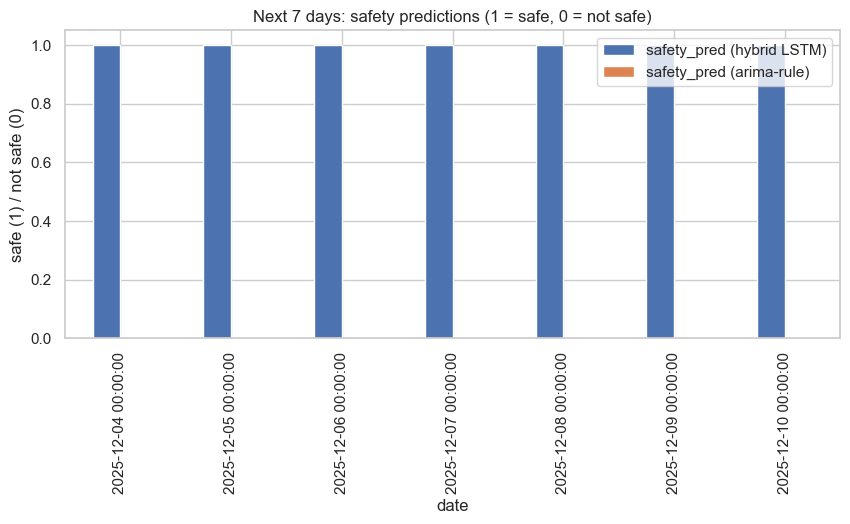

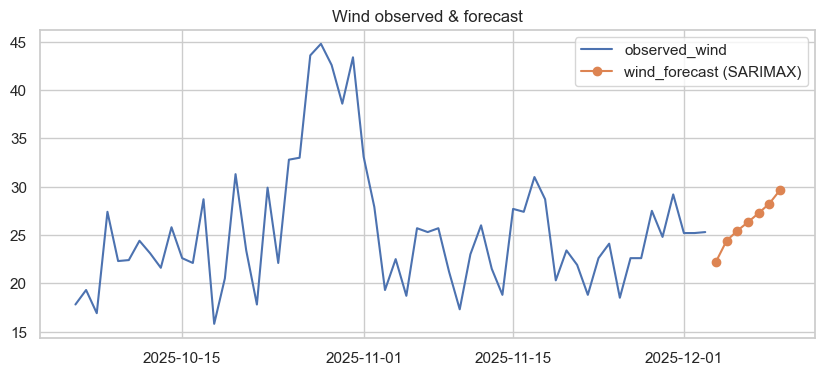

In [41]:
# 9. Visualize
compare_df[['safety_pred (hybrid LSTM)', 'safety_pred (arima-rule)']].plot(kind='bar', figsize=(10,4))
plt.title("Next {} days: safety predictions (1 = safe, 0 = not safe)".format(N))
plt.ylabel("safe (1) / not safe (0)")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df.index[-60:], df[ col_wind].iloc[-60:], label='observed_wind')
plt.plot(future_dates, wind_fc.values, label='wind_forecast (SARIMAX)', marker='o')
plt.legend(); plt.title('Wind observed & forecast')
plt.show()

In [44]:

# If holdout_df covers the same future dates, compare:
if len(holdout_df) >= N and list(holdout_df.index[:N]) == list(future_dates):
    y_true = holdout_df['safe_for_fishing'].iloc[:N].values
    y_hybrid = np.array(hybrid_preds)
    print("Hybrid Accuracy over first {} holdout days:".format(N), accuracy_score(y_true, y_hybrid))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_hybrid))
else:
    print("Holdout not aligned or too short for direct N-day evaluation. Provide holdout covering forecast period to evaluate.")

# 11. Save artifacts
clf.save('lstm_fishing_classifier.pkl')
joblib.dump(scaler, 'scaler_fishing.pkl')
res_wind.save('res_wind_sarimax.pickle')  # saves model results
print("Saved: lstm_fishing_classifier.h5, scaler_fishing.pkl, res_wind_sarimax.pickle")

# 12. Notes & next steps
print("""
Notes:
- Thresholds (WIND_MAX_THRESH, TEMP_MIN_THRESH) are configurable.
- For better multi-day performance, forecast temperature (apparent_temperature_mean (°C)) with SARIMAX too
  and feed those forecasts into the hybrid pipeline (instead of persisting last temp).
- Tune SARIMAX order with pmdarima.auto_arima for improved wind forecasts.
- If class imbalance exists, use class_weight or resampling when training the LSTM.
- For deterministic ARIMA-only safety, you can also forecast rain_sum (mm) and precipitation_hours to incorporate rain.
""")

Holdout not aligned or too short for direct N-day evaluation. Provide holdout covering forecast period to evaluate.
Saved: lstm_fishing_classifier.h5, scaler_fishing.pkl, res_wind_sarimax.pickle

Notes:
- Thresholds (WIND_MAX_THRESH, TEMP_MIN_THRESH) are configurable.
- For better multi-day performance, forecast temperature (apparent_temperature_mean (°C)) with SARIMAX too
  and feed those forecasts into the hybrid pipeline (instead of persisting last temp).
- Tune SARIMAX order with pmdarima.auto_arima for improved wind forecasts.
- If class imbalance exists, use class_weight or resampling when training the LSTM.
- For deterministic ARIMA-only safety, you can also forecast rain_sum (mm) and precipitation_hours to incorporate rain.



In [45]:
# 11. Save artifacts
clf.save('lstm_fishing_classifier.pkl')
joblib.dump(scaler, 'scaler_fishing.pkl')
res_wind.save('res_wind_sarimax.pickle')  # saves model results
print("Saved: lstm_fishing_classifier.h5, scaler_fishing.pkl, res_wind_sarimax.pickle")

INFO:tensorflow:Assets written to: lstm_fishing_classifier.pkl\assets


INFO:tensorflow:Assets written to: lstm_fishing_classifier.pkl\assets


Saved: lstm_fishing_classifier.h5, scaler_fishing.pkl, res_wind_sarimax.pickle


In [57]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import statsmodels.api as sm

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------


# Ensure target exists
if "safe_for_fishing" not in df.columns:
    raise Exception("Column 'safe_for_fishing' is missing!")

# input features for safety prediction
feature_cols = [
    "wind_speed_10m_max (km/h)",
    "weather_code (wmo code)",
    "apparent_temperature_mean (°C)",
    "rain_sum (mm)",
    "precipitation_sum (mm)"
]

X = df[feature_cols]
y = df["safe_for_fishing"]

# --------------------------------------------------
# 2. SCALE FEATURES
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# 3. TRAIN TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --------------------------------------------------
# 4. TRAIN RANDOM FOREST CLASSIFIER
# --------------------------------------------------

clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train, y_train)

# --------------------------------------------------
# 5. EVALUATE MODEL
# --------------------------------------------------

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# --------------------------------------------------
# 6. SAVE CLASSIFIER + SCALER
# --------------------------------------------------

pickle.dump(clf, open("classifier.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Saved: classifier.pkl & scaler.pkl")

# --------------------------------------------------
# 7. TRAIN ARIMA MODEL FOR WIND FORECAST
# --------------------------------------------------

wind_series = df["wind_speed_10m_max (km/h)"]

# Fit simple SARIMAX
arima_model = sm.tsa.statespace.SARIMAX(
    wind_series,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Save ARIMA model
pickle.dump(arima_model, open("wind_arima.pkl", "wb"))

print("Saved: wind_arima.pkl")


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       415
           1       1.00      1.00      1.00        18

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433

Saved: classifier.pkl & scaler.pkl


C:\Users\BHAGYASHREE\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Saved: wind_arima.pkl


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }


In [59]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt





def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

metrics = get_metrics(y_true, y_pred)

# Pie chart
def plot_metrics_pie(metrics_dict):
    labels = list(metrics_dict.keys())
    values = list(metrics_dict.values())

    fig, ax = plt.subplots()
    ax.pie(values, labels=labels, autopct="%1.1f%%")
    ax.set_title("Model Performance Metrics")





plot_metrics_pie(metrics)


ValueError: Found input variables with inconsistent numbers of samples: [10, 433]